# PA005 - High Value Customer Identification (Insiders)

# SOLUTION PLANNING

"All in one place" is an online retail store that sells second-hand products from various brands at lower prices.

With just over a year of operation, the marketing team noticed that some customers from their base purchase more expensive products more frequently, contributing significantly to the company's revenue.

Based on this insight, the marketing team decided to launch a loyalty program for the top customers in their base, named Insiders. However, the marketing team lacks the necessary knowledge to select the participating customers for this program.

As a result, this task was assigned to the company's data team, where a solution that ultimately provides a list of customers to be invited to participate in the Insiders program should be developed. Additionally, a report answering the following questions should be delivered:

1. Who are the eligible individuals to participate in the program?
   - Faturamento:
        - Alto ticket medio
        - Alto LTV
        - Baixa recencia
        - Baixa probabilidade de churn
        - Alta previsao LTV
        - Alta propensao de compra

    - Custo:
        - Baixa taxa de devolucao

   - Experiencia de Compra
        - Media alta das avaliacoes    

2. How many customers will be part of the group?
   - Numero total de clientes
   - % do grupo insiders
    
3.  What are the main characteristics of these customers?
    - Escrever caracteristicas do cliente:
      - Idade
      - Localizacao
       
    - Escrever caracteristicas do consumo:
      - Atributos da clusterizacao

4. What percentage of the revenue comes from the selected group?
    - Faturamento total do ano
    - Faturamento do grupo Insiders

5. What is the revenue expectation for this group in the upcoming months?
    - LTV do grupo Insiders
    - Analise de Cohort
    
6. What are the conditions for someone to be eligible for the group?
   - Definir a periodicidade ( 1 month, 2 month, etc.). 
   - A pessoa precisa ser similar com uma outra pessoa do grupo.

7. What are the conditions for someone to be removed from the group?
   - Definir a periodicidade ( 1 month, 2 month, etc.). 
   - A pessoa precisa ser desimilar com uma outra pessoa do grupo.
   
8. What assurance is there that the group is better than the rest of the base?
   - Teste A/B.
   - Teste A/B Bayesiano.
   - Teste de hipotese.

9. What actions can the marketing team take to increase revenue?
   - Desconto
   - Preferencia de Compra
   - Visitar empresa

**SOLUTION PLANNING**

1 - Input:
    Business Problem: Hight value customers identification and selection in order to join a loyalty program.
    Dataset: sales datas from an e-commerce, collected trough an one year period.

2 - Output:
    List containing the customer identification and if they are eligible or not to the loyalty program.
    Report, answering the business questions and explaining how the selection was made.
    
3 - Tasks
    - Who are the eligible individuals to participate in the program?
        Understanding of what elegible means and what are the most valuable customer.
        
        
    - How many customers will be part of the group?
        
        
    - What are the main characteristics of these customers?
        
    
    - What percentage of the revenue comes from the selected group?
        
    
    - What is the revenue expectation for this group in the upcoming months?
        
    
    - What are the conditions for someone to be eligible for the group?
        
    
    - What are the conditions for someone to be removed from the group?
        
    
    - What assurance is there that the group is better than the rest of the base?
        
    
    - What actions can the marketing team take to increase revenue?
        


# 0 - IMPORTS </font>

In [1]:
# Data Maniputalion and Data Analysis
import re
import warnings

import pandas                as pd
import seaborn               as sns
import numpy                 as np

from ydata_profiling         import ProfileReport
from matplotlib              import pyplot          as plt

# ML Algorithms
import umap.umap_            as umap

from sklearn.manifold        import TSNE
from sklearn                 import preprocessing as pp
from sklearn                 import ensemble      as en
from sklearn                 import decomposition as dd
from sklearn                 import cluster       as cc
from sklearn                 import metrics       as mt
from sklearn                 import ensemble      as en
from yellowbrick.cluster     import KElbowVisualizer, SilhouetteVisualizer

# Loading Images and display settings
from IPython.display         import Image, display
from IPython.core.display    import HTML

warnings.filterwarnings( 'ignore' )

## 0.1 - Helper Functions

In [2]:
def drop_and_rename_duplicate_columns(df):
    """
    Remove colunas duplicadas resultantes de um merge e renomeia as colunas para eliminar o sufixo '_x'.
    Remove linhas referentes a invoices canceladas ou devolvidas: cujo valor para a coluna `invoice_status_y` for igual a 'True'.
    
    Parâmetros:
    - df (pd.DataFrame): DataFrame resultante de um merge com possíveis colunas duplicadas.

    Retorna:
    - pd.DataFrame: DataFrame com colunas duplicadas removidas e renomeadas.
    """

    # Verifica se a coluna 'invoice_status_y' existe e filtra onde o valor é True
    if 'invoice_cancelled_y' in df.columns:
        df = df[~df['invoice_cancelled_y'].fillna(False)]
    
    # Identifica colunas com sufixos '_x' e '_y' após o merge
    duplicate_columns = [col for col in df.columns if col.endswith('_x') or col.endswith('_y')]
    
    # Cria um mapeamento para manter apenas uma ocorrência e renomear as colunas
    cols_to_keep = {}
    for col in duplicate_columns:
        base_name = col[:-2]  # Remove o sufixo '_x' ou '_y'
        if base_name not in cols_to_keep:
            # Guarda a coluna com sufixo '_x' para manter e renomear
            cols_to_keep[base_name] = col

    # Define as colunas para remoção, mantendo apenas uma de cada par duplicado
    cols_to_drop = set(duplicate_columns) - set(cols_to_keep.values())
    df = df.drop(columns=cols_to_drop)

    # Renomeia as colunas restantes, removendo o sufixo '_x'
    df = df.rename(columns={old_name: base_name for base_name, old_name in cols_to_keep.items()})

    # Filtra as colunas, removendo invoice_cancelled
    cols = ['invoice_no', 'stock_code', 'description', 'quantity', 'invoice_date','unit_price', 'customer_id', 'country']

    return df[cols]

# 1 - DATA LOADING

## 1.1 - LOADING DATA

In [3]:
df = pd.read_csv("../data/raw/Ecommerce.csv")

# drop extra column
df = df.drop( columns=['Unnamed: 8'], axis=1)

## 1.2 - DATA DESCRIPTIVE

### 1.2.1 - RENAME COLUMNS

In [4]:
df1 = df.copy()

In [5]:
cols_new = ['invoice_no','stock_code','description','quantity','invoice_date','unit_price','customer_id','country']
df1.columns = cols_new

### 1.2.2 - DATA DIMENSIONS

In [6]:
print('Number of columns: {}'.format( df1.shape[1] ) )
print('Number of rows: {}'.format( df1.shape[0] ) )

Number of columns: 8
Number of rows: 541909


### 1.2.3 - DATA TYPES

In [7]:
df1.dtypes

invoice_no       object
stock_code       object
description      object
quantity          int64
invoice_date     object
unit_price      float64
customer_id     float64
country          object
dtype: object

### 1.2.4 - CHECK NA VALUES

In [8]:
df1.isna().sum()

invoice_no           0
stock_code           0
description       1454
quantity             0
invoice_date         0
unit_price           0
customer_id     135080
country              0
dtype: int64

#### 1.2.4.1 - HANDLING MISSING VALUES

In [9]:
# To analyse the data, two new data set are being created:
df_missing = df1.loc[df1['customer_id'].isna(), :] # Contains the data with missing customer_id
df_not_missing = df1.loc[~df1['customer_id'].isna(),:] # Contain the data with customer_id

In [10]:
df_not_missing.isna().sum()

invoice_no      0
stock_code      0
description     0
quantity        0
invoice_date    0
unit_price      0
customer_id     0
country         0
dtype: int64

In [11]:
df_missing.isna().sum()

invoice_no           0
stock_code           0
description       1454
quantity             0
invoice_date         0
unit_price           0
customer_id     135080
country              0
dtype: int64

In [12]:
# Identifying which are the invoices without customer id
missing_invoice = df_missing['invoice_no'].drop_duplicates().tolist()

# Locate the missing customer_id data by searching from invoice_no
df_aux = df_not_missing.loc[df_not_missing['invoice_no'].isin(missing_invoice)]

# Print result if any
df_aux.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country


In [13]:
# The analysis will continue with the data set without NaN values
df1 = df_not_missing.copy()

**COMMENTS:**

Registers with missing description also has a missing customer_id.

Some actions could be taken in order to handle these issues:
An unique customer_id and invoice_no can have more than one register, as the granularity is defined by sotck_code, then:

1) Compare the invoice_no from the dataset containing missing values with the invoice_no from the complete dataset, and fill in the NA values where the entries match by invoice_no;
2) Add a random number to these customers, so the data would not be lost;
3) Drop NaN values;

The decision is to continue the project by doing the check described on (1) and if does not work, the NaN values will be removed, once the aim is to identify the best customers;

### 1.2.5 - CHANGE DTYPES

In [14]:
df1.dtypes

invoice_no       object
stock_code       object
description      object
quantity          int64
invoice_date     object
unit_price      float64
customer_id     float64
country          object
dtype: object

In [15]:
df1[ 'invoice_date'] = pd.to_datetime( df1['invoice_date'], format='%d-%b-%y') # changing the data on the column invoice data to match the correct data type

df1['customer_id'] = df1['customer_id'].astype( int ) # changing the data on the column customer id data to match the correct data type

df1['country'] = df1['country'].astype( str ) # Changing data type from object to string

### 1.2.6 - DESCRIPTIVE STATISTICS

In [16]:
# For Numerical Data
df1.describe().T

,count,mean,min,25%,50%,75%,max,std
quantity,406829.0,12.061303,-80995.0,2.0,5.0,12.0,80995.0,248.69337
invoice_date,406829,2017-07-08 03:16:19.124890624,2016-11-29 00:00:00,2017-04-04 00:00:00,2017-07-29 00:00:00,2017-10-18 00:00:00,2017-12-07 00:00:00,NaN
unit_price,406829.0,3.460471,0.0,1.25,1.95,3.75,38970.0,69.315162
customer_id,406829.0,15287.69057,12346.0,13953.0,15152.0,16791.0,18287.0,1713.600303


In [17]:
# For Categorical Data
df1.describe(include='object').T

,count,unique,top,freq
invoice_no,406829,22190,576339,542
stock_code,406829,3684,85123A,2077
description,406829,3896,WHITE HANGING HEART T-LIGHT HOLDER,2070
country,406829,37,United Kingdom,361878


**INSIGHTS**

*1. QUANTITY*

Approximately 75% of the 406,829 orders contain a maximum of 12 items. The mean and standard deviation appear to be impacted by high values. Upon reviewing the minimum and maximum values, two extremes are evident: the minimum is a negative number that exactly matches the maximum value, which suggests a return, cancellation, or another issue. This anomaly requires further investigation.

*2. UNIT PRICE*

The products appear to be relatively inexpensive, with an average price of 3.46. Additionally, 75% of the 406,829 entries have prices below 3.75. The minimum and maximum values are of particular interest—a minimum price of 0 likely indicates an error, and a maximum of approximately 38,000 suggests issues that should be examined in more detail.

*3. INVOICE NO*

There are 22,190 unique invoice numbers, indicating that the e-commerce platform processed 22,190 transactions during the period from 29/11/2016 to 08/07/2017. Additionally, invoice number 576339 contains 542 entries.

*4. STOCK CODE*

There are 3,684 unique products sold, with product 85123A leading as the top item by transaction volume.

*5. DESCRIPTION*

There are 3,896 unique descriptions compared to 3,684 unique stock codes, suggesting that some products may have multiple descriptions associated with the same stock code.

*6. COUNTRY*

The transactions span 37 different countries, with the majority originating from the UK.

### 1.3 - EDA

#### QUANTITY

Analysing the **quantity** feature, it came to my attention that:

1) Some extremely values of quantity have an very similar data with a negative quantity and the invoice_no starts with "C". In my understanding, it means that some invoices have been canceled or returned.

I will:

Filter and remove the purchase register and the return register from the analysis.

In [18]:
df1.nlargest(5, 'quantity')

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2017-12-07,2.08,16446,United Kingdom
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2017-01-16,1.04,12346,United Kingdom
502122,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,2017-11-23,0.00,13256,United Kingdom
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,2017-10-25,0.21,12901,United Kingdom
206121,554868,22197,SMALL POPCORN HOLDER,4300,2017-05-25,0.72,13135,United Kingdom


In [19]:
df1.nsmallest(5, 'quantity')

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2017-12-07,2.08,16446,United Kingdom
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2017-01-16,1.04,12346,United Kingdom
4287,C536757,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,-9360,2016-11-30,0.03,15838,United Kingdom
160145,C550456,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,-3114,2017-04-16,2.10,15749,United Kingdom
160144,C550456,21175,GIN + TONIC DIET METAL SIGN,-2000,2017-04-16,1.85,15749,United Kingdom


<Axes: xlabel='quantity'>

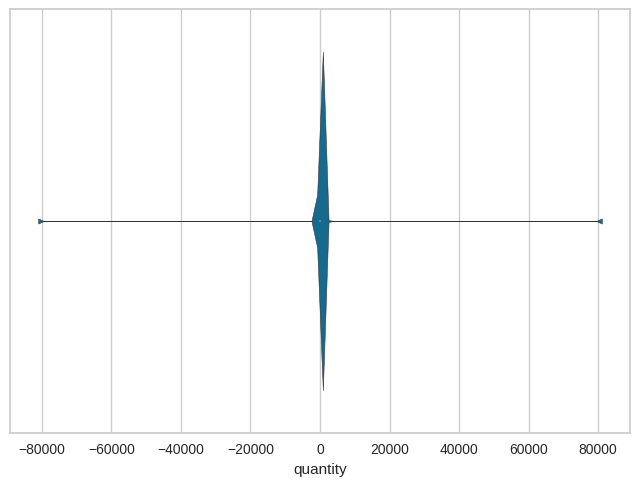

In [20]:
sns.violinplot(x=df1['quantity'])

### UNIT PRICE

There are some items with an extreme values as well as items with price equal to 0; These datas also have some odd stock code and quantities and they would be filtered on the step 2.

In [21]:
df1.nlargest(5, 'unit_price')

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
222681,C556445,M,Manual,-1,2017-06-08,38970.00,15098,United Kingdom
173277,C551685,POST,POSTAGE,-1,2017-05-01,8142.75,16029,United Kingdom
173382,551697,POST,POSTAGE,1,2017-05-01,8142.75,16029,United Kingdom
173391,C551699,M,Manual,-1,2017-05-01,6930.00,16029,United Kingdom
268027,C560372,M,Manual,-1,2017-07-16,4287.63,17448,United Kingdom


In [22]:
df1.nsmallest(5, 'unit_price')

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2016-12-03,0.0,12647,Germany
33576,539263,22580,ADVENT CALENDAR GINGHAM SACK,4,2016-12-14,0.0,16560,United Kingdom
40089,539722,22423,REGENCY CAKESTAND 3 TIER,10,2016-12-19,0.0,14911,EIRE
47068,540372,22090,PAPER BUNTING RETROSPOT,24,2017-01-04,0.0,13081,United Kingdom
47070,540372,22553,PLASTERS IN TIN SKULLS,24,2017-01-04,0.0,13081,United Kingdom


<Axes: xlabel='unit_price'>

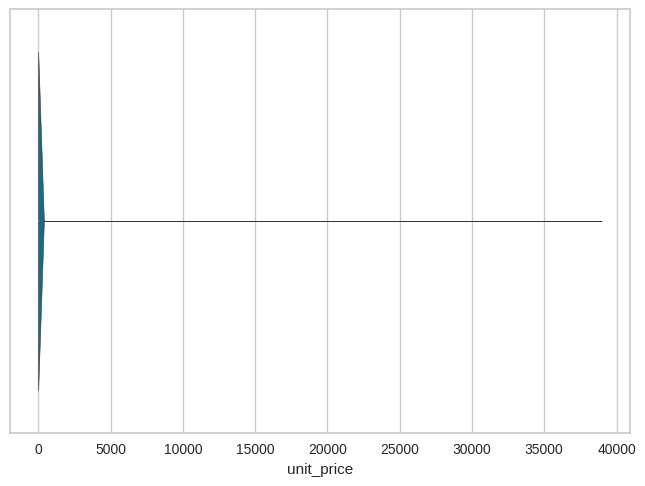

In [23]:
sns.violinplot(x=df1['unit_price'])

### STOCK CODE

While analysing the data, it come to attention some stcock_code that does not reffers to products. A filter will be added, aiming to:

POST - Remove. It seems to be a delivery price. Need's to be confirmed with the company;

M    - Keep. It seems to be manual insertions and legit acquisition;

C2   - Remove. It seems to be a delivery price. Need's to be confirmed with the company;

D    - Remove. It is a discount applied on some acquisitions;

DOT  - Remove. It seems to be a delivery price. Need's to be confirmed with the company;

CRUK - Remove. It seems to be kind of comission.

PADS - Remove. Need's to be confirmed

BANK CHARGES - Remove. Bank fees

In [24]:
df1["length_sc"] = df1["stock_code"].str.strip().str.len()

df1["length_sc"].value_counts(normalize=True)

length_sc
5     0.911980
6     0.082573
4     0.002989
1     0.001332
7     0.000728
2     0.000329
3     0.000039
12    0.000029
Name: proportion, dtype: float64

In [25]:
df1[df1["length_sc"] < 5]["stock_code"].value_counts(normalize=True)

stock_code
POST    0.626834
M       0.243711
C2      0.070231
D       0.040356
DOT     0.008386
CRUK    0.008386
PADS    0.002096
Name: proportion, dtype: float64

In [26]:
df1[df1["length_sc"] > 6]["stock_code"].value_counts(normalize=True)

stock_code
15056BL         0.961039
BANK CHARGES    0.038961
Name: proportion, dtype: float64

Stock codes to be removed from the analysis
['POST','C2','DOT','PADS','BANK CHARGES'] 


### COUNTRY

There are 345 registers where it is not possible to identify the country where the customer is from; Howevere these registers will be kept
once still is possible to identify the customer;

In [27]:
df1['country'].value_counts(normalize=True)

country
United Kingdom          0.889509
Germany                 0.023339
France                  0.020871
EIRE                    0.018398
Spain                   0.006226
Netherlands             0.005828
Belgium                 0.005086
Switzerland             0.004614
Portugal                0.003638
Australia               0.003095
Norway                  0.002669
Italy                   0.001974
Channel Islands         0.001863
Finland                 0.001708
Cyprus                  0.001529
Sweden                  0.001136
Austria                 0.000986
Denmark                 0.000956
Japan                   0.000880
Poland                  0.000838
USA                     0.000715
Israel                  0.000615
Unspecified             0.000600
Singapore               0.000563
Iceland                 0.000447
Canada                  0.000371
Greece                  0.000359
Malta                   0.000312
United Arab Emirates    0.000167
European Community      0.000150
RS

In [28]:
# How many registers does not specify the country?

dfc_aux = df1[['country', 'customer_id']].groupby('country').count().reset_index()
dfc_aux = dfc_aux.sort_values(by='customer_id', ascending=False).reset_index(drop=True)
dfc_aux[dfc_aux['country'].isin(['Unspecified', 'European Community'])]


,country,customer_id
22,Unspecified,244
29,European Community,61


### QUESTIONS TO ANWSWER:

In [29]:
- Qual cliente comprou mais?
- Qual cliente devolveu mais?
- Qual produto foi o mais vendido?
- Qual produto foi o mais devolvido/cancelado?
- Qual mes vendeu mais?
- Qual mes vendeu menos?
- Qual dia da semana vendeu mais?
- Qual dia da semana vendeu menos?
- Qual pais concentra a maior parte do faturamento?

Object `mais` not found.
Object `mais` not found.
Object `vendido` not found.
Object `cancelado` not found.
Object `mais` not found.
Object `menos` not found.
Object `mais` not found.
Object `menos` not found.
Object `faturamento` not found.


# 2 - DATA FILTERING

On this project, the step **DATA FILTERING** will be done earlier as some features are been calculated from the dataset and are combined with that dataset later on, and it's our duty to make sure that we are keeping our data clean and without errors.

In [30]:
df2 = df1.copy()

In [31]:
# REMOVING REGISTERS WHERE THE PURCHASE HAVE BEEN RETURNED OR CANCELLED
# Classifing each invoice as cancelled (True) or not (False) 
df2['invoice_cancelled'] = df2['invoice_no'].str.startswith("C") & (df2['quantity']<0)

# Separting two datasets:
aux_cancelled = df2[df2['invoice_cancelled']] # invoices cancelled
aux_not_cancelled = df2[~df2['invoice_cancelled']] # invoices not cancelled

# Mergin the above two data sets
merged_df = aux_not_cancelled.merge(aux_cancelled, on=['stock_code','unit_price','customer_id'], how='left')

# Applying function to clean the new data set by removing columns etc.
df2 = drop_and_rename_duplicate_columns(merged_df)

# --- NUMERICAL ATTRIBUTES ---

# Filtering products where price is equal to 0
df2 = df2.loc[df2['unit_price'] > 0, :]

# --- CATEGORICAL ATTRIBUTES ---

# Filtering stock_codes that does not reffers to items
df2 = df2[~df2['stock_code'].isin( ['POST','C2','DOT','PADS','BANK CHARGES'] )]

# Description
df2 = df2.drop( columns='description', axis=1)

# Quantity
df2_returns = aux_cancelled.copy()
df2_purchases = aux_not_cancelled.copy()

In [32]:
df2.shape

(380785, 7)

# 3 - FATURE ENGINEERING

In [33]:
df3 = df2.copy()

In [34]:
# data reference
df_ref = df3.drop( ['invoice_no','stock_code','quantity','invoice_date','unit_price','country'],axis=1).drop_duplicates(ignore_index=True)

## 3.1 - Gross Revenue

In [35]:
# Calculus of the monetary value sold
df2.loc[:,'gross_revenue'] = df2.loc[:,'quantity'] * df2.loc[:,'unit_price']
df_sold = df2.loc[:, ['customer_id', 'gross_revenue']].groupby('customer_id').sum().reset_index()

df_ref = pd.merge( df_ref, df_sold, on='customer_id', how='left')

df_ref.isna().sum()

customer_id      0
gross_revenue    0
dtype: int64

In [36]:
df_ref.head()

,customer_id,gross_revenue
0,17850,4046.51
1,13047,2392.96
2,12583,6507.44
3,13748,948.25
4,15291,4396.00


In [37]:
# # Calculus of the monetary value returned
# df2_returns.loc[:,'total_amount_returned'] = df2_returns.loc[:,'quantity'] * df2_returns.loc[:,'unit_price']
# df_returned = df2_returns.loc[:, ['customer_id', 'total_amount_returned']].groupby('customer_id').sum().reset_index()

# df_ref = pd.merge( df_ref, df_returned, on='customer_id', how='left')

# # Calculus of the revenue

# df_ref['total_amount_returned'] = df_ref['total_amount_returned'].fillna(0) # If there is none returns, it means that the quantity is equal to 0.

# df_ref['gross_revenue'] = abs(df_ref['total_amount_sold']) - abs(df_ref['total_amount_returned'])

## 3.2 - Recency - Day from last purchase

In [38]:
# Recency
df_recency = df2.loc[:, ['customer_id', 'invoice_date']].groupby('customer_id').max().reset_index()
df_recency['recency_days'] = (df2['invoice_date'].max() - df_recency['invoice_date']).dt.days
df_recency = df_recency[['customer_id','recency_days']].copy()
df_ref = pd.merge( df_ref, df_recency, on='customer_id', how='left')

df_ref.isna().sum()

customer_id      0
gross_revenue    0
recency_days     0
dtype: int64

In [39]:
df_ref.head()

,customer_id,gross_revenue,recency_days
0,17850,4046.51,372
1,13047,2392.96,31
2,12583,6507.44,2
3,13748,948.25,95
4,15291,4396.00,25


## 3.3 - Qty of purchases

In [40]:
df_freq = (df2.loc[:, ['customer_id', 'invoice_no']].drop_duplicates()
                                                    .groupby('customer_id')
                                                    .count()
                                                    .reset_index()
                                                    .rename( columns={'invoice_no':'qty_invoices'}) )
                
df_ref = pd.merge(df_ref, df_freq, on='customer_id', how='left')

df_ref.isna().sum()

customer_id      0
gross_revenue    0
recency_days     0
qty_invoices     0
dtype: int64

In [41]:
df_ref.head()

,customer_id,gross_revenue,recency_days,qty_invoices
0,17850,4046.51,372,34
1,13047,2392.96,31,10
2,12583,6507.44,2,15
3,13748,948.25,95,5
4,15291,4396.00,25,15


## 3.4 Qty of products purchased

In [42]:
# Number of products
df_freqp = ( df2.loc[:,['customer_id', 'quantity']].groupby('customer_id')
                                                   .sum().reset_index()
                                                   .rename( columns={'quantity':'qty_prod_purchased'}) )

df_ref = pd.merge(df_ref, df_freqp, on='customer_id', how='left')
df_ref.isna().sum()

customer_id           0
gross_revenue         0
recency_days          0
qty_invoices          0
qty_prod_purchased    0
dtype: int64

In [43]:
df_ref.head()

,customer_id,gross_revenue,recency_days,qty_invoices,qty_prod_purchased
0,17850,4046.51,372,34,1191
1,13047,2392.96,31,10,1159
2,12583,6507.44,2,15,4854
3,13748,948.25,95,5,439
4,15291,4396.00,25,15,1949


## 3.5 - Range of Products per Customer

In [44]:
df_prod = ( df2.loc[:,['customer_id', 'stock_code']].groupby('customer_id')
                                                    .count()
                                                    .reset_index()
                                                    .rename( columns={'stock_code':'range_of_products'}) )
            
df_ref = pd.merge(df_ref, df_prod, on='customer_id', how='left')
df_ref.isna().sum()

customer_id           0
gross_revenue         0
recency_days          0
qty_invoices          0
qty_prod_purchased    0
range_of_products     0
dtype: int64

## 3.6 - Average Ticket Value

In [45]:
# Avg Ticket
df_avg_ticket = ( df2.loc[:, ['customer_id','gross_revenue']].groupby('customer_id')
                                                             .mean()
                                                             .reset_index()
                                                             .rename( columns={'gross_revenue':'avg_ticket'}) )

df_ref = pd.merge( df_ref, df_avg_ticket, on='customer_id', how='left')
df_ref.isna().sum()

customer_id           0
gross_revenue         0
recency_days          0
qty_invoices          0
qty_prod_purchased    0
range_of_products     0
avg_ticket            0
dtype: int64

## 3.7 - Average Recency Days

In [46]:
# df_aux = ( df2_purchases[['customer_id','invoice_date']].drop_duplicates()
#                                                       .sort_values( ['customer_id', 'invoice_date'], ascending=[False, False] ) ) 
    
# df_aux['next_customer_id'] = df_aux['customer_id'].shift() # next customer
# df_aux['previous_date'] = df_aux['invoice_date'].shift() # next invoice date
# df_aux['avg_recency_days'] = df_aux.apply( lambda x: x['invoice_date'] - x['previous_date'] if x['customer_id'] == x['next_customer_id'] else np.nan, axis=1 ).dt.days

# df_recency = df_recency[['customer_id','recency_days']].copy() # calculating the recency day

# df_aux = df_aux.drop(['invoice_date','next_customer_id','previous_date'], axis=1).dropna()# leaving only the interested variable and the customer_id into the aux dataframe

# # calculating the average for customer
# df_avg_recency_days = df_aux.groupby('customer_id').mean().reset_index()

# # meging the result with the original df

# df_ref= pd.merge(df_ref, df_avg_recency_days, on='customer_id', how='left')

# df_ref.isna().sum()

## 3.8 - Frequency of Purchases

In [47]:
df2_max = df2[['customer_id','invoice_date']].drop_duplicates().groupby('customer_id').max().reset_index() # finding the last date of purchase per customer
df2_min = df2[['customer_id','invoice_date']].drop_duplicates().groupby('customer_id').min().reset_index() # finding the last date of purchase per customer

df_aux = ( df2[['customer_id','invoice_no','invoice_date']].drop_duplicates()
                                                           .groupby('customer_id')
                                                           .agg( max_ =('invoice_date', 'max'),
                                                                 min_ =('invoice_date', 'min'),
                                                                 days_=('invoice_date', lambda x:( (x.max() - x.min() ).days)+1),
                                                                 buy_ =('invoice_no', 'count'))).reset_index()

# Frequency
df_aux['frequency'] = df_aux[['buy_', 'days_']].apply( lambda x: x['buy_'] / x['days_'] if x['days_'] != 0 else 0, axis=1 )

# Merge
df_ref = pd.merge(df_ref, df_aux[['customer_id','frequency']], on='customer_id', how='left')

df_ref.isna().sum()

customer_id           0
gross_revenue         0
recency_days          0
qty_invoices          0
qty_prod_purchased    0
range_of_products     0
avg_ticket            0
frequency             0
dtype: int64

## 3.9 - Qty avg of producst per customer

In [48]:
df_ref['avg_qty_products_purchased'] = df_ref['qty_prod_purchased'] / df_ref['qty_invoices']
df_ref.isna().sum()

customer_id                   0
gross_revenue                 0
recency_days                  0
qty_invoices                  0
qty_prod_purchased            0
range_of_products             0
avg_ticket                    0
frequency                     0
avg_qty_products_purchased    0
dtype: int64

In [49]:
df_ref.head()

,customer_id,gross_revenue,recency_days,qty_invoices,qty_prod_purchased,range_of_products,avg_ticket,frequency,avg_qty_products_purchased
0,17850,4046.51,372,34,1191,204,19.835833,17.000000,35.029412
1,13047,2392.96,31,10,1159,130,18.407385,0.029155,115.900000
2,12583,6507.44,2,15,4854,225,28.921956,0.040323,323.600000
3,13748,948.25,95,5,439,28,33.866071,0.017921,87.800000
4,15291,4396.00,25,15,1949,96,45.791667,0.042980,129.933333



# <font color='black'> 4 - EDA </font>

In [52]:
df4 = df_ref.copy()

## 4.1 - Univariate Analysis

Metrics to be checked out:

1. Cluster coesos - separados
2. Metrics:
    - Min, Max, Range (dispersion)
    - Mean and Median
    - Standard Deviation and Variance
    - CV (Coefficient of Variation)
    - Distribuition

In [53]:
prof = ProfileReport(df4)
prof.to_file('data_descriptive.html') 

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

#### 4.1.1 Pandas Profiling Report - Analysis

## 4.2 - Bivariate Analysis

In [ ]:
cols = ['customer_id']
df42 = df4.drop( cols, axis=1 )

In [ ]:
plt.figure( figsize=(12, 15) )


sns.pairplot( df4 )

## 4.3 - Space of Study

In [55]:
df43 = df4.drop( columns=['customer_id'], axis=1 ).copy()

In [56]:
df43.head()

,gross_revenue,recency_days,qty_invoices,qty_prod_purchased,range_of_products,avg_ticket,frequency,avg_qty_products_purchased
0,4046.51,372,34,1191,204,19.835833,17.000000,35.029412
1,2392.96,31,10,1159,130,18.407385,0.029155,115.900000
2,6507.44,2,15,4854,225,28.921956,0.040323,323.600000
3,948.25,95,5,439,28,33.866071,0.017921,87.800000
4,4396.00,25,15,1949,96,45.791667,0.042980,129.933333


In [57]:
#### Standardization

mms = pp.MinMaxScaler()

# Transformer
df43['gross_revenue']                = mms.fit_transform( df43[['gross_revenue']])
df43['recency_days']                 = mms.fit_transform( df43[['recency_days']])
df43['qty_invoices']                 = mms.fit_transform( df43[['qty_invoices']])
df43['qty_prod_purchased']           = mms.fit_transform( df43[['qty_prod_purchased']])
df43['range_of_products']            = mms.fit_transform( df43[['range_of_products']])
df43['avg_ticket']                   = mms.fit_transform( df43[['avg_ticket']])
df43['frequency']                    = mms.fit_transform( df43[['frequency']])
df43['avg_qty_products_purchased']   = mms.fit_transform( df43[['avg_qty_products_purchased']])

X = df43.copy()

### 4.3.1 - PCA

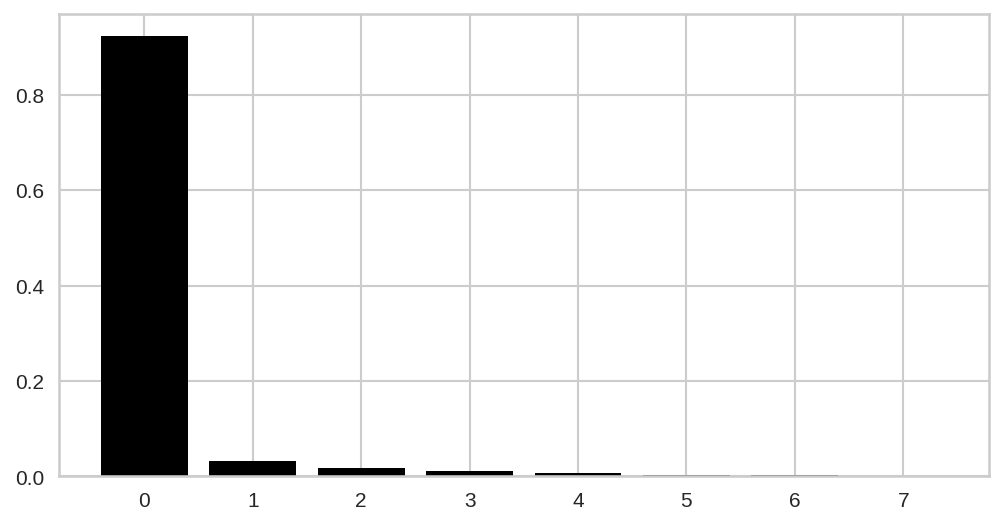

In [58]:
fig, axs = plt.subplots(figsize = (8, 4), dpi=150)
pca = dd.PCA ( n_components = X.shape[1] )

principal_components = pca.fit_transform( X )

# plot explained variables
features = range( pca.n_components_ )

plt.bar( features, pca.explained_variance_ratio_, color='black' )

# pca component

df_pca = pd.DataFrame( principal_components )

<Axes: xlabel='0', ylabel='1'>

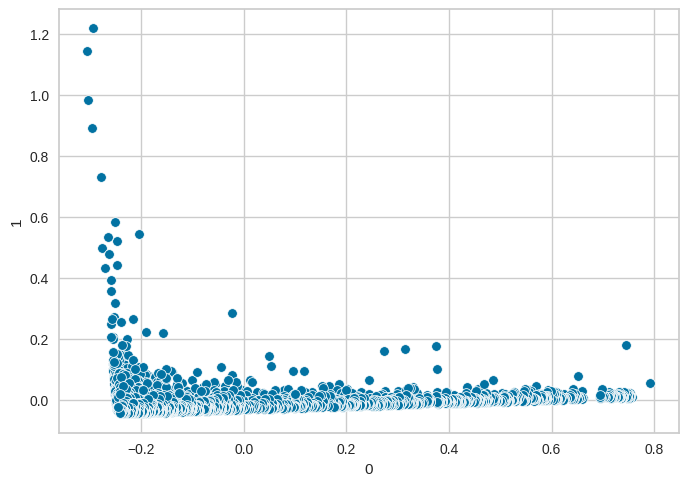

In [59]:
sns.scatterplot( x=0, y=1, data=df_pca)

### 4.3.2 - UMAP

<Axes: xlabel='embedding_x', ylabel='embedding_y'>

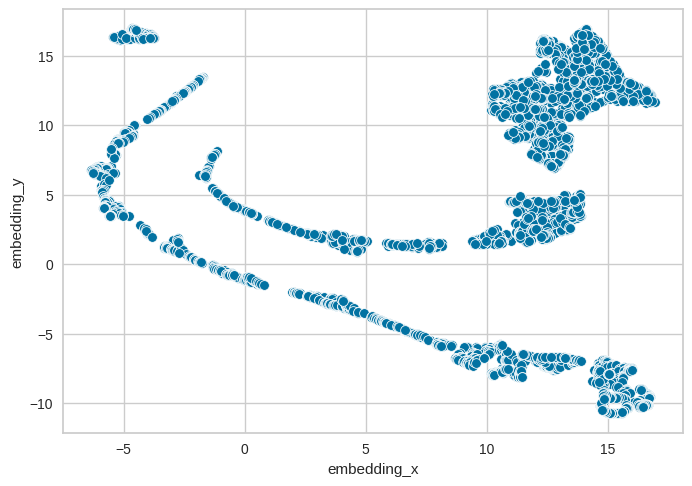

In [60]:
# UMAP 
reducer = umap.UMAP( random_state=42 )
embedding = reducer.fit_transform( X )

# Embedding 
df_pca['embedding_x'] = embedding[:, 0]
df_pca['embedding_y'] = embedding[:, 1]

# Plot UMAP
sns.scatterplot( 
                 x='embedding_x',
                 y='embedding_y',
                 data=df_pca)
                                

### 4.3.3 - TSNE

<Axes: xlabel='embedding_x', ylabel='embedding_y'>

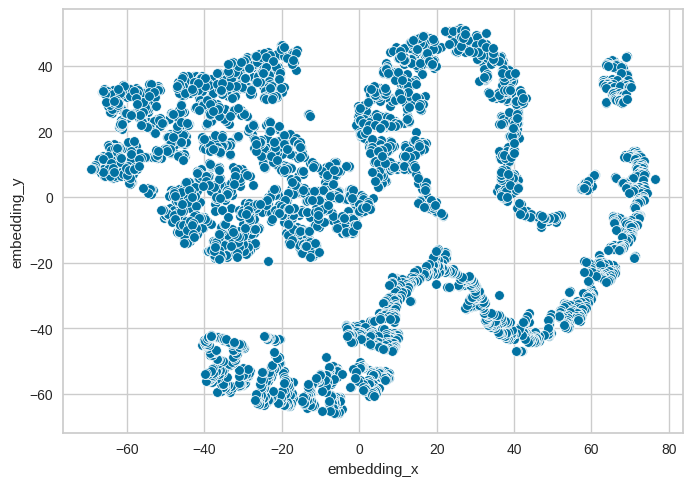

In [61]:
# UMAP 
reducer = TSNE( n_components=2, n_jobs=-1, random_state=42 )
embedding = reducer.fit_transform( X )

# Embedding 
df_pca['embedding_x'] = embedding[:, 0]
df_pca['embedding_y'] = embedding[:, 1]

# Plot UMAP
sns.scatterplot( 
                 x='embedding_x',
                 y='embedding_y',
                 data=df_pca)
                                

### 4.3.4 - Tree-Based Embedding

In [62]:
# Training dataset
X = df4.drop( columns=['customer_id','gross_revenue'], axis=1 ).copy()
y = df4['gross_revenue']

# model definition
rf_model = en.RandomForestRegressor( n_estimators=100, random_state=42 )

# model trainig
rf_model.fit(X,y)

RandomForestRegressor(random_state=42)

In [63]:
df_leaf = pd.DataFrame( rf_model.apply( X ) ) #here i am selecting the datas from the leaf of tree

<Axes: xlabel='embedding_x', ylabel='embedding_y'>

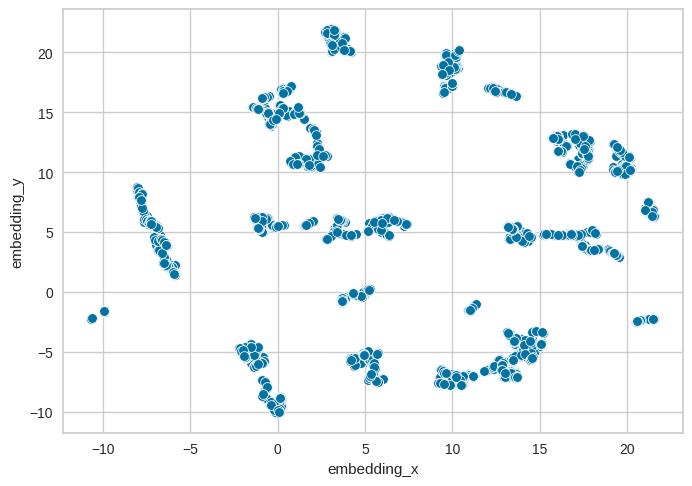

In [64]:
# UMAP 
reducer = umap.UMAP( random_state=42 )
embedding = reducer.fit_transform( df_leaf )

# Embedding 
df_pca['embedding_x'] = embedding[:, 0]
df_pca['embedding_y'] = embedding[:, 1]

# Plot UMAP
sns.scatterplot( 
                 x='embedding_x',
                 y='embedding_y',
                 data=df_pca)

# 5 - DATA PREPARATION

In [69]:
df5 = df4.copy()

In [70]:
df5.head()

,customer_id,gross_revenue,recency_days,qty_invoices,qty_prod_purchased,range_of_products,avg_ticket,frequency,avg_qty_products_purchased
0,17850,4046.51,372,34,1191,204,19.835833,17.000000,35.029412
1,13047,2392.96,31,10,1159,130,18.407385,0.029155,115.900000
2,12583,6507.44,2,15,4854,225,28.921956,0.040323,323.600000
3,13748,948.25,95,5,439,28,33.866071,0.017921,87.800000
4,15291,4396.00,25,15,1949,96,45.791667,0.042980,129.933333


#### Standardization

In [73]:
mms = pp.MinMaxScaler()

# Transformer
df5['gross_revenue']              = mms.fit_transform( df5[['gross_revenue']])
df5['recency_days']               = mms.fit_transform( df5[['recency_days']])
df5['qty_invoices']               = mms.fit_transform( df5[['qty_invoices']])
df5['qty_prod_purchased']         = mms.fit_transform( df5[['qty_prod_purchased']])
df5['range_of_products']        = mms.fit_transform( df5[['range_of_products']])
df5['avg_ticket']                 = mms.fit_transform( df5[['avg_ticket']])
df5['frequency']                  = mms.fit_transform( df5[['frequency']])
df5['avg_qty_products_purchased'] = mms.fit_transform( df5[['avg_qty_products_purchased']])

# <font color='red'> 6 - FEATURE SELECTION </font>

In [74]:
df6 = df5.copy()

# 7 - FINE TUNING

In [75]:
X = df6.drop( columns=['customer_id'])

In [76]:
cluster = [2,3,4,5,6,7]

## 7.1 - K-Means

In [77]:
kmeans_list = []
for k in cluster:
    # Model Definition
    kmeans_model = cc.KMeans( n_clusters=k )

    # Model Training
    kmeans_model.fit( X )
    # Model Predict
    labels = kmeans_model.predict( X )

    # Model Performance
    sil = mt.silhouette_score( X, labels, metric='euclidean')
    kmeans_list.append( sil )

Text(0.5, 1.0, 'KMeans: Silhouette Score x K')

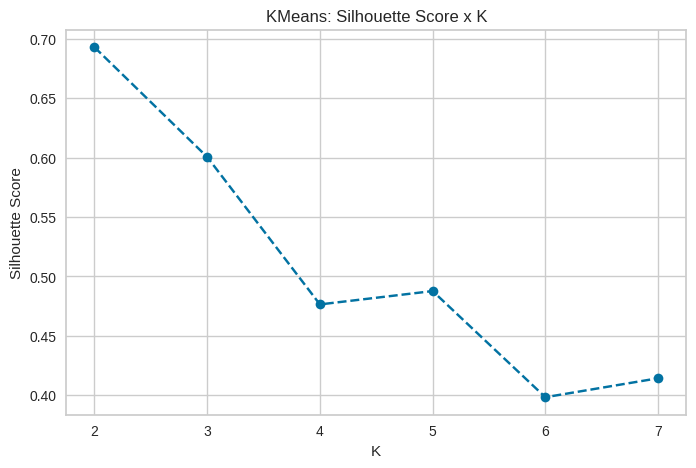

In [78]:
plt.figure( figsize=(8, 5) )
plt.plot( cluster, kmeans_list, linestyle='--', marker='o', color='b')
plt.xlabel( 'K' );
plt.ylabel( 'Silhouette Score');
plt.title('KMeans: Silhouette Score x K')

## 7.2 - Gaussiann Mixture Model

In [79]:
from sklearn import mixture as mx

In [80]:
AIC - Ajuste dos dados
BIC - Ajuste dos parametros

SyntaxError: invalid syntax (1218350061.py, line 1)

In [81]:
gmm_list = [] 
for k in cluster:
    # Model Definition
    gmm_model = mx.GaussianMixture( n_components=k )
    
    # Model Training
    gmm_model.fit( X )

    # Model Predict
    labels = gmm_model.predict( X )

    # Model Performance
    gmm_sil = mt.silhouette_score( X, labels, metric='euclidean')
    gmm_list.append( gmm_sil )

Text(0.5, 1.0, 'GMM: Silhouette Score x K')

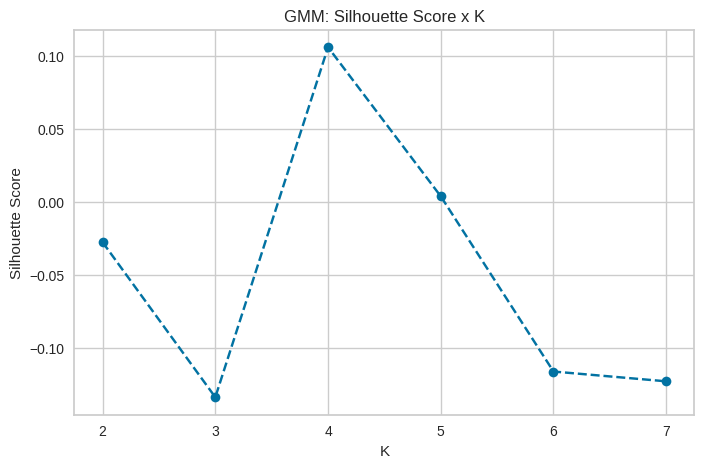

In [82]:
plt.figure( figsize=(8, 5) )
plt.plot( cluster, gmm_list, linestyle='--', marker='o', color='b')
plt.xlabel( 'K' );
plt.ylabel( 'Silhouette Score');
plt.title('GMM: Silhouette Score x K')

## 7.3 - Hierarchical Clustering

In [83]:
from scipy.cluster import hierarchy as hc

In [84]:
# Model Definition and Training
hc_model = hc.linkage( X, 'ward')

[]

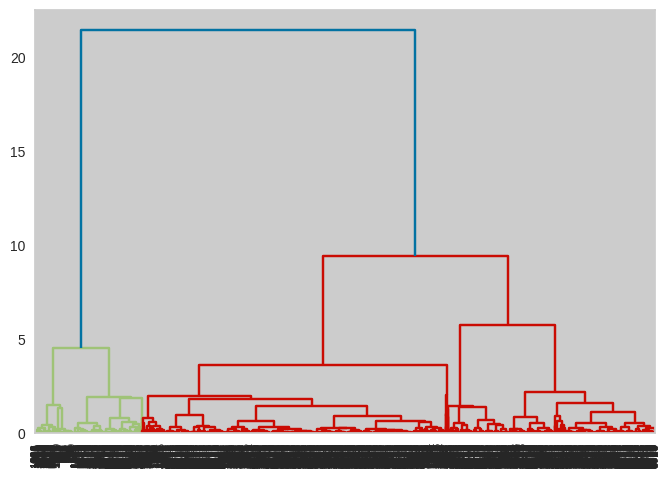

In [85]:
hc.dendrogram(
              hc_model,
              leaf_rotation=90,
              leaf_font_size=8
)

plt.plot()

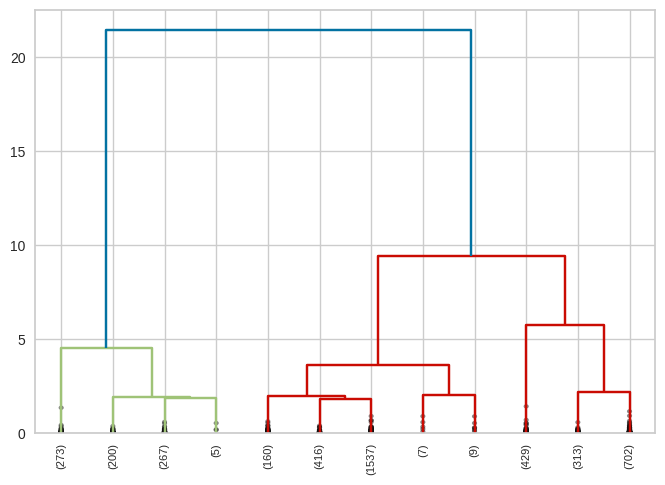

In [86]:
hc.dendrogram(
            hc_model,
            truncate_mode='lastp',
            p=12,
            leaf_rotation=90,
            leaf_font_size=8,
            show_contracted=True
)
plt.show()

### 7.3.1 - Hierarchical Cluster Silhouette

In [87]:
hc_list = []
for k in cluster:
    # Model Definition and Training
    hc_model = hc.linkage( X, 'ward' )

    # Model Predict
    labels = hc.fcluster( hc_model, k, criterion='maxclust' )

    # metrics
    sil = mt.silhouette_score( X, labels, metric='euclidean' )
    hc_list.append( sil )

Text(0.5, 1.0, 'HC: Silhouette Score x K')

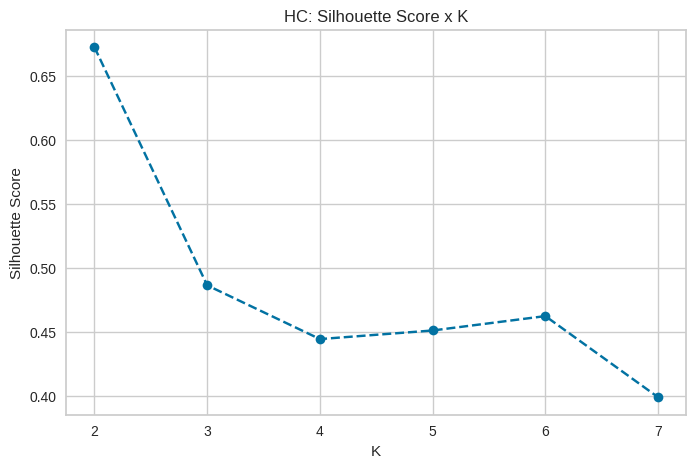

In [88]:
plt.figure( figsize=(8, 5) )
plt.plot( cluster, hc_list, linestyle='--', marker='o', color='b')
plt.xlabel( 'K' );
plt.ylabel( 'Silhouette Score');
plt.title('HC: Silhouette Score x K')

## 7.4 - DBSCAN

In [89]:
eps=0.5
min_samples=20

# Model Definition
dbscan_model = cc.DBSCAN( eps=eps, min_samples=min_samples )

# Model Training and Predict
labels = dbscan_model.fit_predict( X )

sil = mt.silhouette_score( X, labels, metric='euclidean' )
print( 'Silhouette Score: {}'.format( sil ) )
print( 'Number of Cluster: {}'.format( len( unique(labels) ) ) )

Silhouette Score: 0.7479018310500115


NameError: name 'unique' is not defined

In [90]:
from sklearn.neighbors import NearestNeighbors

In [91]:
neighbors = NearestNeighbors( n_neighbors = min_samples).fit( X )
distances, indexes = neighbors.kneighbors( X )

In [92]:
distances = np.sort( distances, axis=0 )
distances = distances[:, 1]

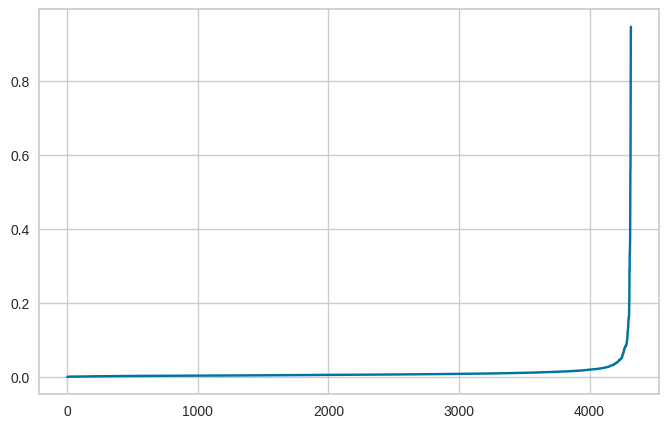

In [93]:
plt.figure( figsize=(8, 5) )
plt.plot( distances )

## 7.5 - Silhouette Analysis

 For K = 2. Silhouette Score: 0.672374962469863


NameError: name 'cm' is not defined

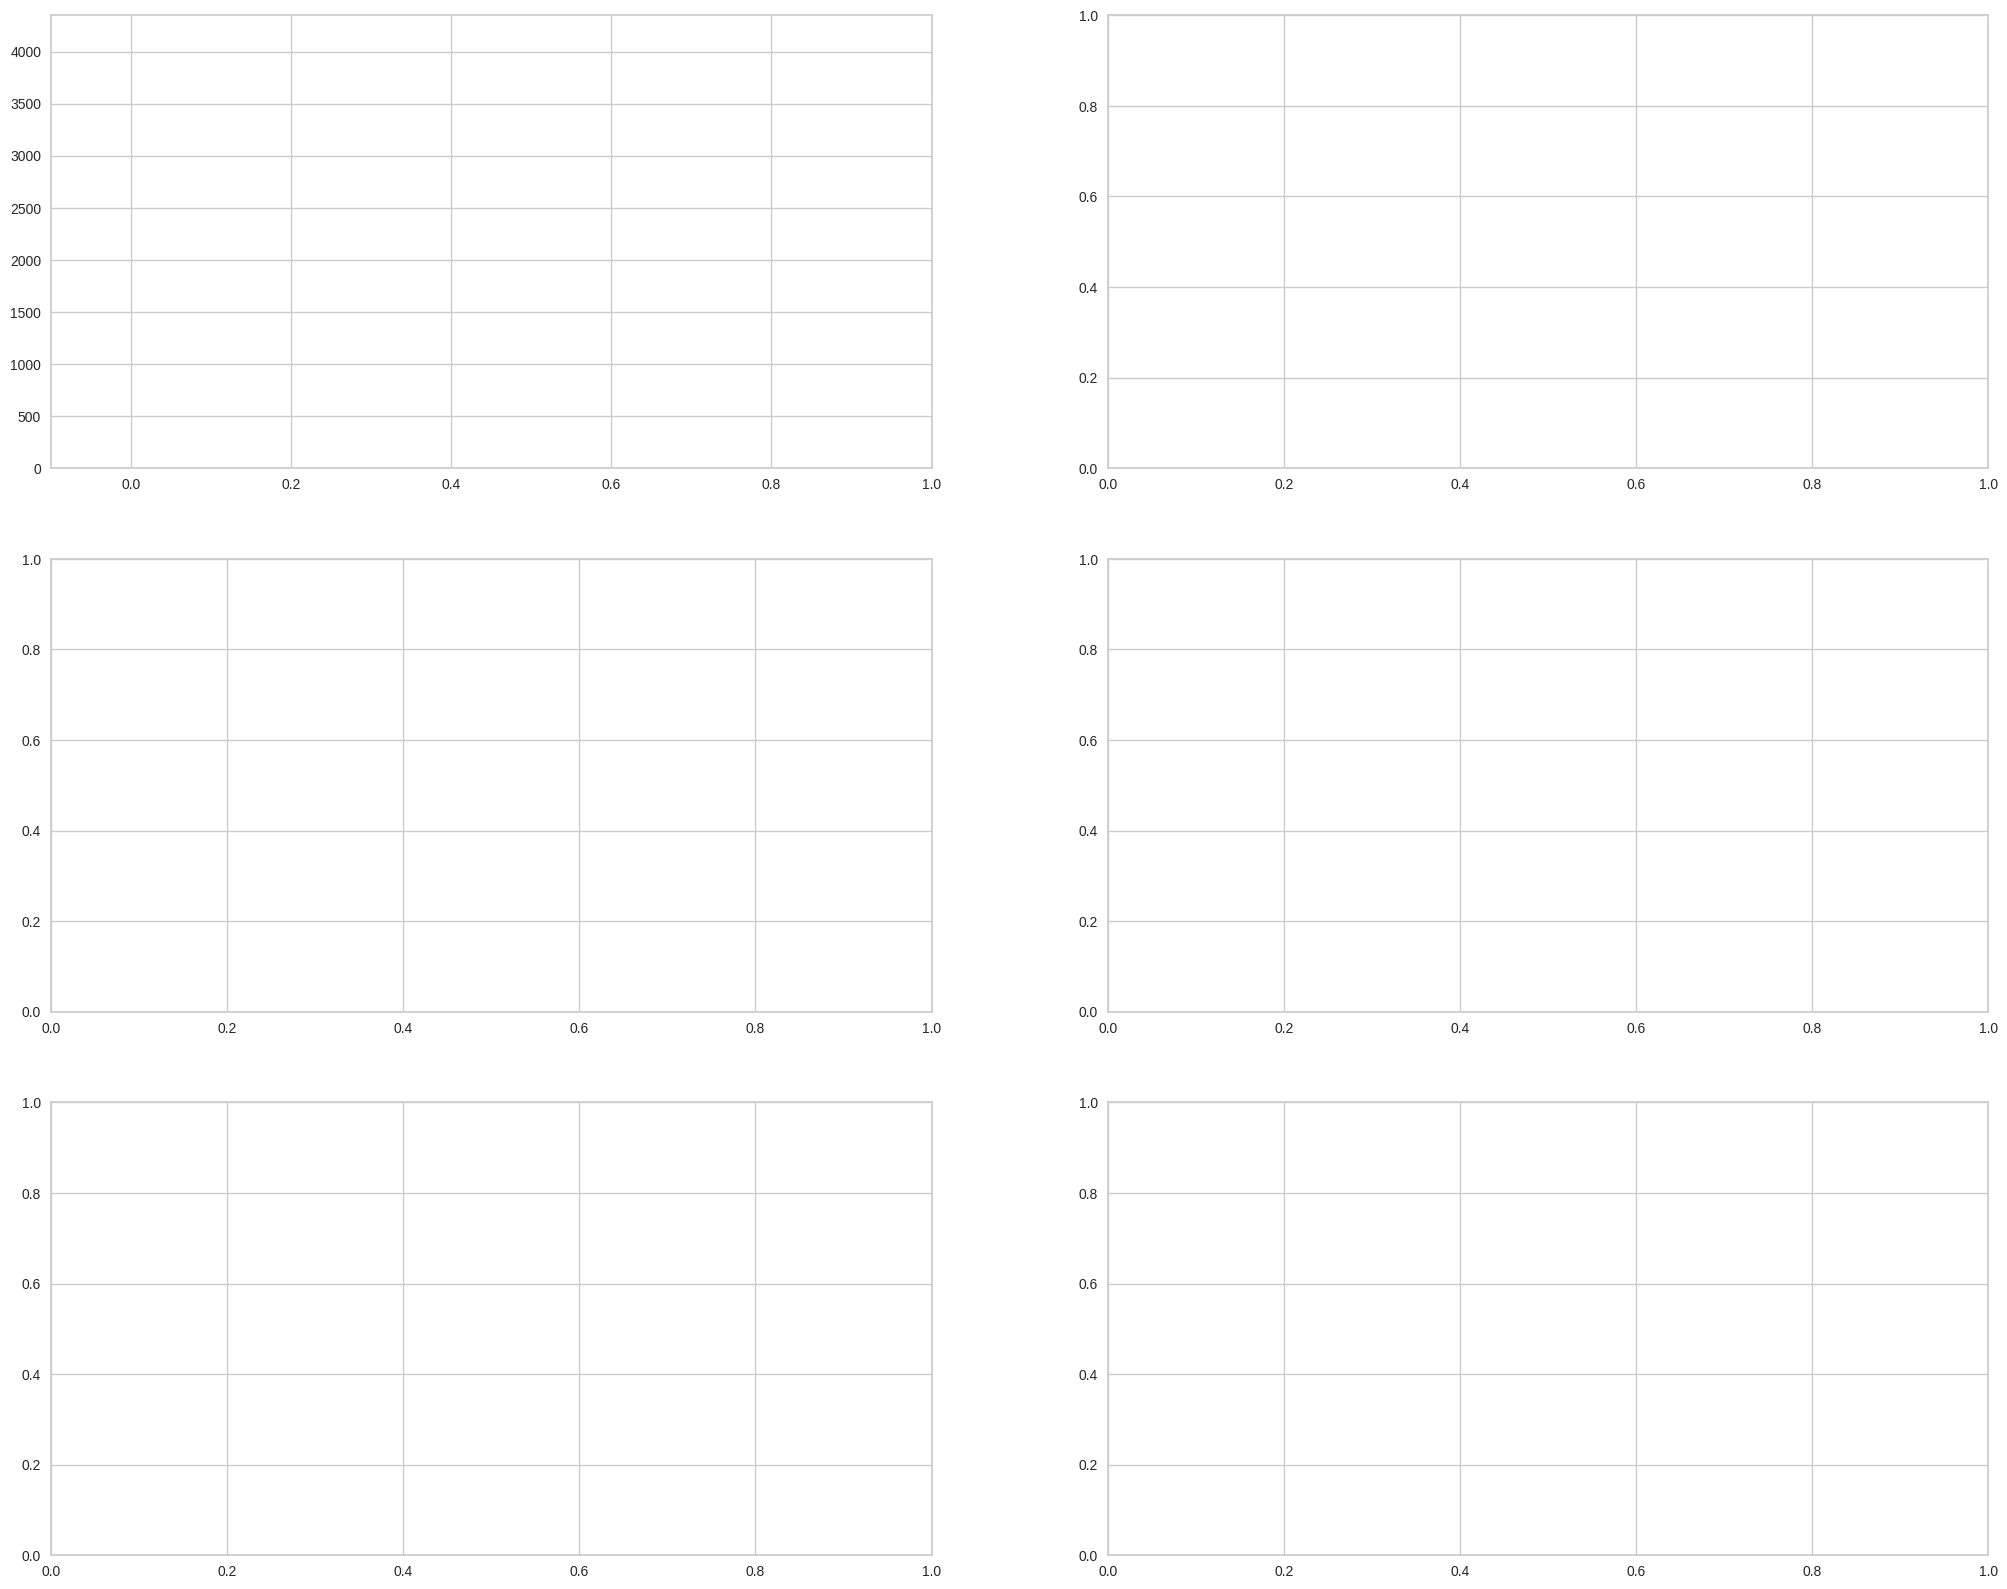

In [94]:
fig, ax = plt.subplots( 3, 2 )
fig.set_size_inches( 25, 20 )

for k in cluster:
    q, mod = divmod( k, 2 )
    
    ax[q-1, mod].set_xlim( [-0.1, 1] )
    ax[q-1, mod].set_ylim( [0, len( X ) + ( k+1 )*10] )
    
    # Model Definition and Training
    hc_model = hc.linkage( X, 'ward')

    # Model Predict
    labels = hc.fcluster( hc_model, k, criterion='maxclust')
    
    # Performance
    ss = mt.silhouette_score( X, labels, metric='euclidean')
    print( ' For K = {}. Silhouette Score: {}'.format( k, ss ) )

    
    samples_silhouette_values = mt.silhouette_samples( X, labels )

    y_lower = 10
    for i in range( k ):
        # Select Clusters
        ith_samples = samples_silhouette_values[ labels == i ]

        # Size Clusters
        size_cluster_i = ith_samples.shape[0]
        
        # Sort values
        ith_samples.sort()    

        # Limits
        y_upper = y_lower + size_cluster_i

        ax[q-1, mod].fill_betweenx( np.arange( y_lower, y_upper ), 0, ith_samples )
        
        y_lower = y_upper + 10 
     
        cmap = cm.get_cmap( 'Spectral')
        color = cmap( i/k )
    
    
    
    
ax[q-1, mod].set_yticks([])
ax[q-1, mod].set_xticks([-0.1, 0.2, 0.4, 0.6, 0.8, 1])

## 7.6 - Results

In [95]:
# Model Name / K=2 / K=3 / K=4 / K=5 / ...
# KMeans       SS    SS    SS    SS
# GMM          SS    SS    SS    SS
# HC           SS    SS    SS    SS
# DBSCAN       SS    SS    SS    SS

In [96]:
df_results = pd.DataFrame(
                          {'KMeans': kmeans_list,
                           'GMM': gmm_list,
                           'HC':hc_list}
).T

df_results.columns = cluster

In [97]:
df_results.style.highlight_max( color='lightgreen', axis=1 ) #identifying the highest value for each ml model

,2,3,4,5,6,7
KMeans,0.693080,0.600634,0.476465,0.487709,0.398300,0.414269
GMM,-0.027534,-0.133629,0.105924,0.003886,-0.116041,-0.122748
HC,0.672375,0.486511,0.444562,0.451273,0.462496,0.399177


# 8 - MACHINE LEARNING TRAINING

In [107]:
# Model Definition
k = 2
kmeans = cc.KMeans( init='random', n_clusters=k, n_init=10, max_iter=300, random_state=42 )

# Model Training
kmeans.fit( X )

# Model Prediction
labels = kmeans.labels_

## 8.1 - Cluster Validation

In [108]:
# WSS
print('WSS value: {}'. format( kmeans.inertia_) )

# Silhouette Score
print( 'SS Score: {}'.format( mt.silhouette_score( X, labels, metric='euclidean' ) ) )

WSS value: 90.85251444043996
SS Score: 0.6930799920206877


# 9 - CLUSTER ANALYSIS

In [109]:
df9 = df6.copy()
df9['cluster'] = labels
df9.head()

,customer_id,gross_revenue,recency_days,qty_invoices,qty_prod_purchased,range_of_products,avg_ticket,frequency,avg_qty_products_purchased,cluster
0,17850,0.014575,0.997319,0.163366,0.006085,0.031202,0.000928,1.000000,0.004350,1
1,13047,0.008615,0.083110,0.044554,0.005922,0.019828,0.000856,0.001395,0.014687,0
2,12583,0.023446,0.005362,0.069307,0.024818,0.034430,0.001387,0.002052,0.041237,0
3,13748,0.003408,0.254692,0.019802,0.002240,0.004150,0.001636,0.000734,0.011095,0
4,15291,0.015835,0.067024,0.069307,0.009962,0.014602,0.002239,0.002208,0.016481,0


## 9.1 - Vizualization Inspection


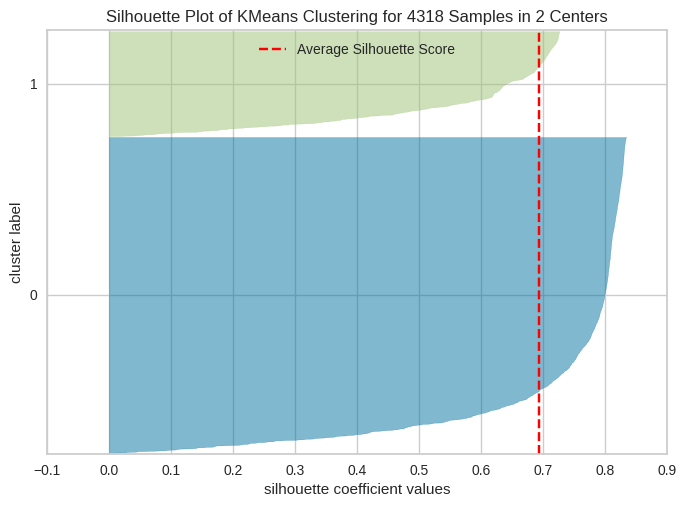

In [110]:
## Silhouette 4 clusters
visualizer = SilhouetteVisualizer( kmeans, colors='yellowbrick' )
visualizer.fit( X )
visualizer.finalize()

## 9.2 - 2D Plot

In [111]:
df9.head()

,customer_id,gross_revenue,recency_days,qty_invoices,qty_prod_purchased,range_of_products,avg_ticket,frequency,avg_qty_products_purchased,cluster
0,17850,0.014575,0.997319,0.163366,0.006085,0.031202,0.000928,1.000000,0.004350,1
1,13047,0.008615,0.083110,0.044554,0.005922,0.019828,0.000856,0.001395,0.014687,0
2,12583,0.023446,0.005362,0.069307,0.024818,0.034430,0.001387,0.002052,0.041237,0
3,13748,0.003408,0.254692,0.019802,0.002240,0.004150,0.001636,0.000734,0.011095,0
4,15291,0.015835,0.067024,0.069307,0.009962,0.014602,0.002239,0.002208,0.016481,0


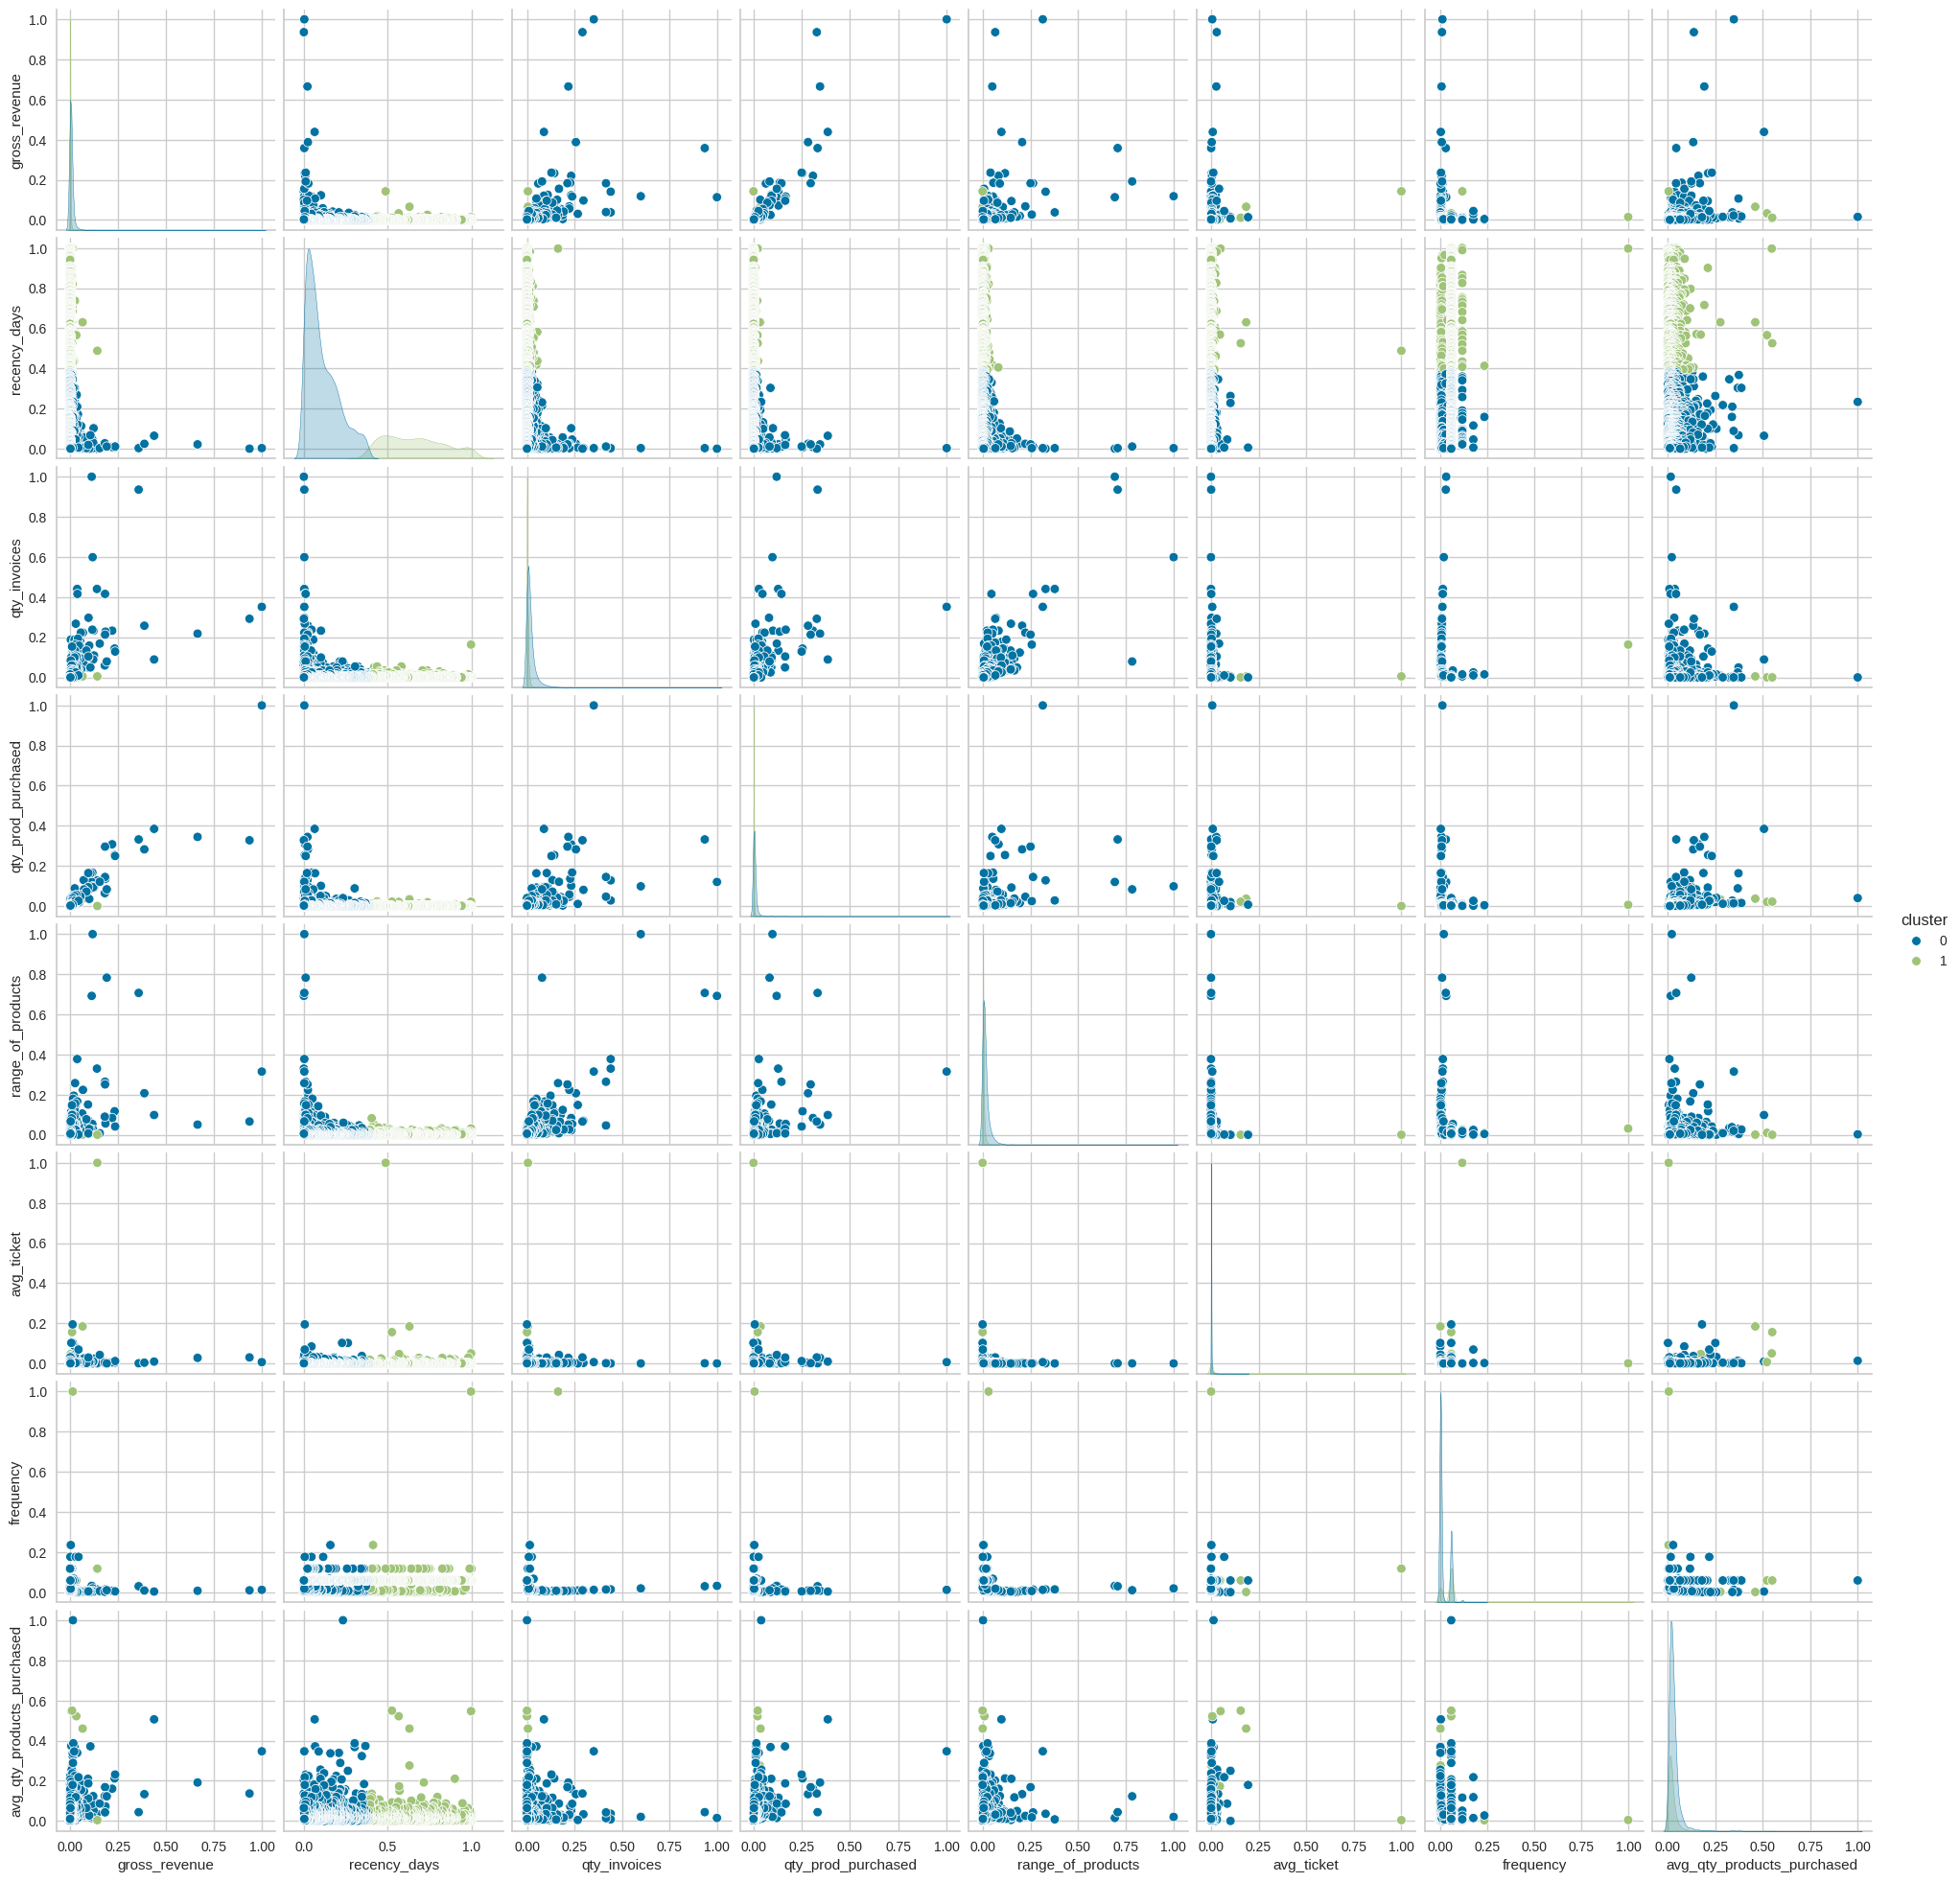

In [112]:
df_viz = df9.drop( columns='customer_id', axis=1)
sns.pairplot( df_viz, hue='cluster')

## 9.3 - UMAP

Machine Learning - Manifold

Aprendizado por topologia: PCA - Metodo baseado em matriz ou espaco entre distancias. Temos 9 condicoes, cumprir 9 colorarios para ter uma garantia de espaco. Espaco de Hilbert, etc.AffinityPropagation

UMAP, T-SNE ( 2009 )- Abordagem por topologia ( Manifold ). Topologia sao grafos em alta dimensionalidade

<Axes: xlabel='embedding_x', ylabel='embedding_y'>

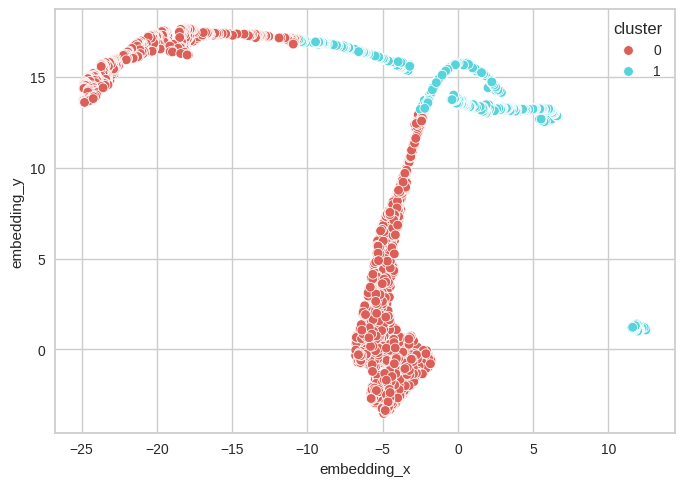

In [113]:
# UMAP 
reducer = umap.UMAP( n_neighbors=90, random_state=42 )
embedding = reducer.fit_transform( X )

# Embedding 
df_viz['embedding_x'] = embedding[:, 0]
df_viz['embedding_y'] = embedding[:, 1]

# Plot UMAP
sns.scatterplot( 
                 x='embedding_x',
                 y='embedding_y', 
                 hue='cluster',
                 palette=sns.color_palette('hls',
                                           n_colors=len(df_viz['cluster'].unique())),
                 data=df_viz)
                                           


## 9.4 - Cluster Profile

In [ ]:
# Number of Customer
df_cluster = df9[['customer_id', 'cluster']].groupby('cluster').count().reset_index()
df_cluster['perc_customer'] = 100*( df_cluster['customer_id'] / df_cluster['customer_id'].sum() )

# Avg Gross Revenue
df_avg_gross_revenue = df9[['gross_revenue', 'cluster']].groupby('cluster').mean().reset_index()
df_cluster = pd.merge( df_cluster, df_avg_gross_revenue, how='inner', on='cluster')

# Avg Recency Days
df_avg_recency_days = df9[['recency_days', 'cluster']].groupby('cluster').mean().reset_index()
df_cluster = pd.merge( df_cluster, df_avg_recency_days, how='inner', on='cluster')

# Avg invoice_no
df_invoice_no = df9[['invoice_no', 'cluster']].groupby('cluster').mean().reset_index()
df_cluster = pd.merge( df_cluster, df_invoice_no, how='inner', on='cluster')

# Avg Ticket
df_avg_ticket = df9[['avg_ticket', 'cluster']].groupby('cluster').mean().reset_index()
df_cluster = pd.merge( df_cluster, df_avg_ticket, how='inner', on='cluster')


In [ ]:
df_cluster.head()

# 10 - DEPOLOY